In [1]:
import pandas as pd
import numpy as np

In [2]:
url = "https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/2023-24/gws/merged_gw.csv"
df = pd.read_csv(url)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29725 entries, 0 to 29724
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        29725 non-null  object 
 1   position                    29725 non-null  object 
 2   team                        29725 non-null  object 
 3   xP                          29725 non-null  float64
 4   assists                     29725 non-null  int64  
 5   bonus                       29725 non-null  int64  
 6   bps                         29725 non-null  int64  
 7   clean_sheets                29725 non-null  int64  
 8   creativity                  29725 non-null  float64
 9   element                     29725 non-null  int64  
 10  expected_assists            29725 non-null  float64
 11  expected_goal_involvements  29725 non-null  float64
 12  expected_goals              29725 non-null  float64
 13  expected_goals_conceded     297

In [4]:
df.sort_values(['name','GW'],inplace=True)

minutes → (if playing) goals + assists + bonus → total_points

In [5]:
df['points_last3_avg']=df.groupby('name')['total_points'].transform(lambda x:x.shift(1).rolling(3).mean())
df['points_last5_avg']=df.groupby('name')['total_points'].transform(lambda x:x.shift(1).rolling(5).mean())
df['minutes_last5_avg']=df.groupby('name')['minutes'].transform(lambda x:x.shift(1).rolling(5).mean())
df['goals_last5_avg']=df.groupby('name')['goals_scored'].transform(lambda x:x.shift(1).rolling(5).mean())
df['assists_last5_avg']=df.groupby('name')['assists'].transform(lambda x:x.shift(1).rolling(5).mean())
df['bps_last5_avg']=df.groupby('name')['bps'].transform(lambda x:x.shift(1).rolling(5).mean())

In [6]:
df.drop(columns=[
    'assists','bonus','clean_sheets','element','fixture','goals_scored','kickoff_time','own_goals',
    'penalties_missed','penalties_saved','red_cards','round',
    'selected','team_a_score','team_h_score','transfers_in','minutes',
    'transfers_out','ict_index','yellow_cards','starts','bps','saves','goals_conceded'
],inplace=True)

In [7]:
df[df['name']=='Erling Haaland']['xP']

445       5.5
1064      8.0
1713      7.8
2410     10.8
3123     11.0
3840     10.0
4616      5.7
5369      3.8
6098      5.0
6829      9.2
7562      9.3
8303     12.0
9048      6.4
9801      8.8
10555     9.0
11313     7.9
12027     1.1
13466     1.4
14239     0.0
15021     0.0
15816     1.5
16621     3.0
17433     7.3
18365    13.6
18366    13.6
19118     0.0
19892     7.8
20785     5.1
22000     3.3
22844     1.8
23690     4.0
24541     6.5
25564     3.8
26563     4.2
27456    10.0
28499    17.9
28500    17.9
29450     8.2
Name: xP, dtype: float64

In [8]:
print(df[['points_last3_avg','points_last5_avg',
          'goals_last5_avg','assists_last5_avg',
          'minutes_last5_avg','bps_last5_avg']].isna().sum())

points_last3_avg     2599
points_last5_avg     4323
goals_last5_avg      4323
assists_last5_avg    4323
minutes_last5_avg    4323
bps_last5_avg        4323
dtype: int64


In [9]:
cutoff=30
train_data=df[df['GW']<=cutoff]
test_data=df[df['GW']>cutoff]

In [10]:
train_data.shape

(22269, 23)

In [11]:
test_data.shape

(7456, 23)

In [12]:
type(train_data)

pandas.core.frame.DataFrame

In [13]:
train_data['total_points'].mean()

np.float64(1.0734204499528492)

In [14]:
test_data['total_points'].mean()

np.float64(0.98806330472103)

In [15]:
train_data['value'].mean()

np.float64(48.39283308635323)

In [16]:
test_data['value'].mean()

np.float64(47.71875)

In [17]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        22269 non-null  object 
 1   position                    22269 non-null  object 
 2   team                        22269 non-null  object 
 3   xP                          22269 non-null  float64
 4   creativity                  22269 non-null  float64
 5   expected_assists            22269 non-null  float64
 6   expected_goal_involvements  22269 non-null  float64
 7   expected_goals              22269 non-null  float64
 8   expected_goals_conceded     22269 non-null  float64
 9   influence                   22269 non-null  float64
 10  opponent_team               22269 non-null  int64  
 11  threat                      22269 non-null  float64
 12  total_points                22269 non-null  int64  
 13  transfers_balance           22269 

In [18]:
drop=['name','GW','team','total_points','expected_goals_conceded','xP','influence','expected_goals','expected_assists','creativity','expected_goal_involvements','threat']

xTrain=train_data.drop(columns=drop)
yTrain=train_data['total_points']

xTest=test_data.drop(columns=drop)
yTest=test_data['total_points']


In [19]:
print("xTrain:", xTrain.shape)
print("yTrain:", yTrain.shape)
print("xTest :", xTest.shape)
print("yTest :", yTest.shape)

xTrain: (22269, 11)
yTrain: (22269,)
xTest : (7456, 11)
yTest : (7456,)


In [20]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop='first',sparse_output=False)

pos_new_train=ohe.fit_transform(xTrain[['position']])
pos_new_test=ohe.transform(xTest[['position']])

encoded_cols_train = ohe.get_feature_names_out(['position'])
encoded_cols_test = ohe.get_feature_names_out(['position'])

df_encoded_train = pd.DataFrame(pos_new_train, columns=encoded_cols_train)
df_encoded_test = pd.DataFrame(pos_new_test, columns=encoded_cols_test)


train_data2 = pd.concat([xTrain.drop('position', axis=1), df_encoded_train], axis=1)
test_data2 = xTest.reset_index(drop=True)
test_data2 = pd.concat([xTest.drop('position', axis=1), df_encoded_test], axis=1)

xTrain = pd.concat([xTrain.drop('position', axis=1), df_encoded_train], axis=1)
xTest = xTest.reset_index(drop=True)
xTest = pd.concat([xTest.drop('position', axis=1), df_encoded_test], axis=1)


In [21]:
xTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7456 entries, 0 to 7455
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   opponent_team      7456 non-null   int64  
 1   transfers_balance  7456 non-null   int64  
 2   value              7456 non-null   int64  
 3   was_home           7456 non-null   bool   
 4   points_last3_avg   7383 non-null   float64
 5   points_last5_avg   7318 non-null   float64
 6   minutes_last5_avg  7318 non-null   float64
 7   goals_last5_avg    7318 non-null   float64
 8   assists_last5_avg  7318 non-null   float64
 9   bps_last5_avg      7318 non-null   float64
 10  position_FWD       7456 non-null   float64
 11  position_GK        7456 non-null   float64
 12  position_MID       7456 non-null   float64
dtypes: bool(1), float64(9), int64(3)
memory usage: 706.4 KB


In [22]:
print("xTrain:", xTrain.shape)
print("yTrain:", yTrain.shape)
print("xTest :", xTest.shape)
print("yTest :", yTest.shape)

xTrain: (22269, 13)
yTrain: (22269,)
xTest : (7456, 13)
yTest : (7456,)


In [23]:
xTrain['was_home'] = xTrain['was_home'].astype(bool)
xTest['was_home']  = xTest['was_home'].astype(bool)

In [24]:
print(yTrain.shape)
xTrain.shape

(22269,)


(22269, 13)

In [25]:
xTrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   opponent_team      22269 non-null  int64  
 1   transfers_balance  22269 non-null  int64  
 2   value              22269 non-null  int64  
 3   was_home           22269 non-null  bool   
 4   points_last3_avg   19743 non-null  float64
 5   points_last5_avg   18084 non-null  float64
 6   minutes_last5_avg  18084 non-null  float64
 7   goals_last5_avg    18084 non-null  float64
 8   assists_last5_avg  18084 non-null  float64
 9   bps_last5_avg      18084 non-null  float64
 10  position_FWD       22269 non-null  float64
 11  position_GK        22269 non-null  float64
 12  position_MID       22269 non-null  float64
dtypes: bool(1), float64(9), int64(3)
memory usage: 2.2 MB


In [28]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

model=xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
)

model.fit(xTrain,yTrain)
yPred=model.predict(xTest)

In [29]:
print("xTrain:", xTrain.shape)
print("yTrain:", yTrain.shape)
print("xTest :", xTest.shape)
print("yTest :", yTest.shape)


xTrain: (22269, 13)
yTrain: (22269,)
xTest : (7456, 13)
yTest : (7456,)


In [30]:
print("MAE",mean_absolute_error(yTest,yPred))
print("RMSE",root_mean_squared_error(yTest,yPred))
print("R2",r2_score(yTest,yPred))

MAE 0.8629610538482666
RMSE 1.885995626449585
R2 0.3206045627593994


points_last3_avg     0.451630
value                0.077604
minutes_last5_avg    0.075006
transfers_balance    0.069719
was_home             0.047614
assists_last5_avg    0.045263
position_MID         0.039679
points_last5_avg     0.038955
position_FWD         0.037792
opponent_team        0.034690
bps_last5_avg        0.032317
goals_last5_avg      0.031536
position_GK          0.018194
dtype: float32

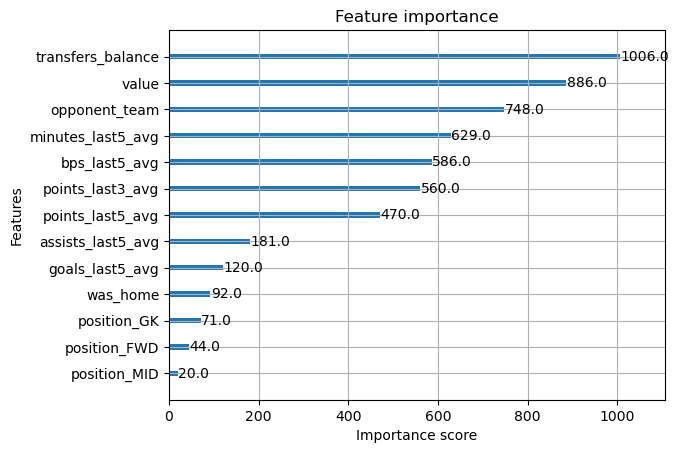

In [31]:
xgb.plot_importance(model,max_num_features=15)
pd.Series(model.feature_importances_, index=list(xTrain.columns)).sort_values(ascending=False)


In [32]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        22269 non-null  object 
 1   position                    22269 non-null  object 
 2   team                        22269 non-null  object 
 3   xP                          22269 non-null  float64
 4   creativity                  22269 non-null  float64
 5   expected_assists            22269 non-null  float64
 6   expected_goal_involvements  22269 non-null  float64
 7   expected_goals              22269 non-null  float64
 8   expected_goals_conceded     22269 non-null  float64
 9   influence                   22269 non-null  float64
 10  opponent_team               22269 non-null  int64  
 11  threat                      22269 non-null  float64
 12  total_points                22269 non-null  int64  
 13  transfers_balance           22269 

In [33]:
baseline_pred = yTrain.mean()
baseline_mae  = mean_absolute_error(train_data['total_points'], [baseline_pred] * len(train_data))
print("Baseline MAE:", baseline_mae)
print("Model MAE:   ", 0.87)

Baseline MAE: 1.4090625828347343
Model MAE:    0.87


In [34]:
print("Target mean:", train_data['total_points'].mean())
print("Target std :", train_data['total_points'].std())
print("Target max :", train_data['total_points'].max())
print("Target min :", train_data['total_points'].min())

Target mean: 1.0734204499528492
Target std : 2.294753874815538
Target max : 23
Target min : -4


In [35]:
from scipy.stats import spearmanr

test = test_data.copy()
test['pred'] = yPred

results = []
for gw in sorted(test['GW'].unique()):
    gw_df = test[test['GW'] == gw]
    corr, _ = spearmanr(gw_df['pred'], gw_df['total_points'])
    actual_top5 = set(gw_df.nlargest(5, 'total_points')['name'])
    pred_top5   = set(gw_df.nlargest(5, 'pred')['name'])
    overlap     = len(actual_top5 & pred_top5) / 5
    results.append({'GW': gw, 'spearman': corr, 'prec@5': overlap})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("Mean Spearman:", results_df['spearman'].mean())
print("Mean Prec@5  :", results_df['prec@5'].mean())

 GW  spearman  prec@5
 31  0.705463     0.2
 32  0.725296     0.0
 33  0.648726     0.0
 34  0.668901     0.2
 35  0.710158     0.0
 36  0.699747     0.0
 37  0.709036     0.0
 38  0.674431     0.0
Mean Spearman: 0.6927197639863052
Mean Prec@5  : 0.05


In [36]:
import numpy as np
yTrain_shuffled = yTrain.sample(frac=1.0, random_state=42).values
model_shuffled = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model_shuffled.fit(xTrain, yTrain_shuffled)
preds_shuffled = model_shuffled.predict(xTest)

In [37]:
from scipy.stats import spearmanr

test = test_data.copy()
test['pred'] = preds_shuffled

results = []
for gw in sorted(test['GW'].unique()):
    gw_df = test[test['GW'] == gw]
    corr, _ = spearmanr(gw_df['pred'], gw_df['total_points'])
    actual_top5 = set(gw_df.nlargest(5, 'total_points')['name'])
    pred_top5   = set(gw_df.nlargest(5, 'pred')['name'])
    overlap     = len(actual_top5 & pred_top5) / 5
    results.append({'GW': gw, 'spearman': corr, 'prec@5': overlap})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("Mean Spearman:", results_df['spearman'].mean())
print("Mean Prec@5  :", results_df['prec@5'].mean())

 GW  spearman  prec@5
 31 -0.112279     0.0
 32 -0.059900     0.0
 33 -0.112913     0.0
 34 -0.099224     0.0
 35 -0.027182     0.0
 36 -0.068363     0.0
 37  0.010104     0.2
 38 -0.064571     0.0
Mean Spearman: -0.06679107131289125
Mean Prec@5  : 0.025


In [38]:
import joblib

joblib.dump(model, 'fpl_model.pkl')
joblib.dump(ohe, 'ohe.pkl')
joblib.dump(list(xTrain.columns), 'features.pkl')

print("Saved.")
print("Feature count:", len(xTrain.columns))
print("Features:", list(xTrain.columns))

Saved.
Feature count: 13
Features: ['opponent_team', 'transfers_balance', 'value', 'was_home', 'points_last3_avg', 'points_last5_avg', 'minutes_last5_avg', 'goals_last5_avg', 'assists_last5_avg', 'bps_last5_avg', 'position_FWD', 'position_GK', 'position_MID']


In [39]:
xTrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   opponent_team      22269 non-null  int64  
 1   transfers_balance  22269 non-null  int64  
 2   value              22269 non-null  int64  
 3   was_home           22269 non-null  bool   
 4   points_last3_avg   19743 non-null  float64
 5   points_last5_avg   18084 non-null  float64
 6   minutes_last5_avg  18084 non-null  float64
 7   goals_last5_avg    18084 non-null  float64
 8   assists_last5_avg  18084 non-null  float64
 9   bps_last5_avg      18084 non-null  float64
 10  position_FWD       22269 non-null  float64
 11  position_GK        22269 non-null  float64
 12  position_MID       22269 non-null  float64
dtypes: bool(1), float64(9), int64(3)
memory usage: 2.2 MB


In [40]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        22269 non-null  object 
 1   position                    22269 non-null  object 
 2   team                        22269 non-null  object 
 3   xP                          22269 non-null  float64
 4   creativity                  22269 non-null  float64
 5   expected_assists            22269 non-null  float64
 6   expected_goal_involvements  22269 non-null  float64
 7   expected_goals              22269 non-null  float64
 8   expected_goals_conceded     22269 non-null  float64
 9   influence                   22269 non-null  float64
 10  opponent_team               22269 non-null  int64  
 11  threat                      22269 non-null  float64
 12  total_points                22269 non-null  int64  
 13  transfers_balance           22269 

In [41]:
train_data2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   opponent_team      22269 non-null  int64  
 1   transfers_balance  22269 non-null  int64  
 2   value              22269 non-null  int64  
 3   was_home           22269 non-null  bool   
 4   points_last3_avg   19743 non-null  float64
 5   points_last5_avg   18084 non-null  float64
 6   minutes_last5_avg  18084 non-null  float64
 7   goals_last5_avg    18084 non-null  float64
 8   assists_last5_avg  18084 non-null  float64
 9   bps_last5_avg      18084 non-null  float64
 10  position_FWD       22269 non-null  float64
 11  position_GK        22269 non-null  float64
 12  position_MID       22269 non-null  float64
dtypes: bool(1), float64(9), int64(3)
memory usage: 2.2 MB


In [ ]:
# This should already exist in your notebook: the full df with lag features
# Just save the columns the app will need for filtering + serving

serving_cols = ['name', 'position', 'value', 'GW',
                'opponent_team', 'transfers_balance', 'was_home',
                'points_last3_avg', 'points_last5_avg',
                'minutes_last5_avg', 'goals_last5_avg',
                'assists_last5_avg', 'bps_last5_avg']

serving_df = df[serving_cols].copy()
serving_df.to_parquet('serving_data.parquet', index=False)

print("Serving shape:", serving_df.shape)
print("GW range:", serving_df['GW'].min(), "-", serving_df['GW'].max())

Serving shape: (29725, 13)
GW range: 1 - 38


In [48]:
import pandas as pd
import joblib

model = joblib.load('fpl_model.pkl')
ohe   = joblib.load('ohe.pkl')
features = joblib.load('features.pkl')

serving_df = pd.read_parquet('serving_data.parquet')

# Simulate a user request
user_budget = 100      # 8.0M in FPL, stored as 80
user_position = 'GK'
user_gw = 33

# Filter candidates
candidates = serving_df[
    (serving_df['GW'] == user_gw) &
    (serving_df['position'] == user_position) &
    (serving_df['value'] <= user_budget)
].copy()

print("Candidate count:", len(candidates))

# Encode position
pos_encoded = ohe.transform(candidates[['position']])
pos_df = pd.DataFrame(pos_encoded, columns=ohe.get_feature_names_out(['position']), index=candidates.index)

# Build feature matrix
X = pd.concat([candidates.drop(columns=['name','position','GW']), pos_df], axis=1)

# Ensure column order matches training
X = X[features]

# Predict
candidates['pred'] = model.predict(X)

# Top 5
top5 = candidates.nlargest(5, 'pred')[['name', 'value', 'pred']]
print(top5)

Candidate count: 96
                    name  value      pred
4737   Caoimhin Kelleher     39  4.601158
10348  Guglielmo Vicario     53  3.818681
19535       Mark Flekken     46  3.537854
1982         André Onana     49  3.364822
15132    Jordan Pickford     47  3.326260
